機械学習の流れ
Pythonで機械学習プログラムを作る際の、大まかな流れは、次の通りです。

1.データを読み込む
2.データの前処理を行なう
3データを訓練データ（train data）とテストデータ（evaluate data）に分ける
4.モデルを作成して訓練する
5.期待する性能が出たかを評価する

In [1]:
#データを読み込む,scikit-learnにあらかじめ用意されているサンプルデータを利用
from sklearn import datasets
irisdata = datasets.load_iris()

In [2]:
#scikit-learnに含まれるサンプルデータは、その書式やデータの意味が DESCR プロパティに記載されています。次のようにして確認
print(irisdata.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

「Sepal Length（がく片の長さ）」「Sepal Width（がく片の幅）」「Petal Length（花びらの長さ）」「Petal Width（花びらの幅）」の4つのデータが irisdata の data プロパティに格納され、それらが「Setosa」「Versicolor」「Virginica」のどの品種に属するかが irisdata の target プロパティに格納されています。

target には SetosaVersicolorVirginica の文字列そのものではなく、012 の整数値が入っています。これは、Setosa = 0, Versicolor = 1, Virginica = 2を意味しています（カテゴリ値: 詳細は後述）。

「アヤメに関する4つの長さ」のように、それぞれがどういう特徴を持っているかを説明するデータを 特徴量 と言います。特徴量は 説明変数とも言います。

また、「アヤメのカテゴリ値」のように、それが何の種類に属しているかを示すデータを 目的変数 といいます。

scikit-learnに含まれるサンプルデータは data プロパティに説明変数（特徴量）が、target プロパティに目的変数が入っています。

In [3]:
irisdata.data #data プロパティに説明変数（特徴量）

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
irisdata.target #target プロパティに目的変数,targetは、このように「0」「1」「2」のいずれかの値になっており、「Setosa」「Versicolor」「Virginica」のそれぞれに対応

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
#data と target は、それぞれ配列（ndarray）です。shape プロパティを参照することで、配列の要素数がわかる
print(irisdata.data.shape)
print(irisdata.target.shape)

(150, 4)
(150,)


data は 縦150行 x 横4列 の配列、target は 縦150行 x 横1列 の配列です。data と target は番号（添字）の同じ要素がペアとなっています。たとえば、0番目の要素の data（説明変数）である [5.1 3.5 1.4 0.2] に対応するtarget（目的変数）は、同じ0番目の要素である0となります。

In [6]:
#data の横の列がそれぞれ何のデータか、また、target の値 0,1,2 がそれぞれ何を表しているかは、以下のプロパティを参照
print(irisdata.feature_names)
print(irisdata.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [7]:
#以降のコードでは、特徴量（説明変数）のデータを X、目的変数のデータを y という変数で利用します。このタイミングで、それぞれの変数に格納しておきます
X = irisdata.data
y = irisdata.target

データの前処理を行なう
正しいデータであっても、説明変数間の単位が大きく違うと、適切に学習できないことがあります。そこで必要になるのが、データの 前処理 
●カテゴリ値の数値化:機械学習では、数値を扱います。たとえば「ネコ」「イヌ」「風景」のカテゴリに分類するモデルを作る場合、この文字を扱うのではなく ネコ = 0, イヌ = 1, 風景 = 2 のように数値化します。このように数値化されたデータをカテゴリ値という
●ダミー変数化:カテゴリ値の数値化とも関連しますが、機械学習の計算方式（アルゴリズム）によっては、テストの点数のように「数値の大小に意味がある」という認識となってしまい、適切に学習できないことがあります。横軸に項目名を持ち、「0」か「1」かを持つ変数マトリックスに展開するように分解します。これを ダミー変数 と言います
●欠損データの補完（穴埋め）:データが一部欠損している場合、補完（穴埋め） することを検討します。「0」として扱うのか、「前後の平均で補完するか」、そもそも全部を捨ててしまうか、などを決めます
●情報保護に関連する加工（マスキング）:個人を特定する部分を隠すマスキングなどの処理をします
●画像や音声を処理しやすくする加工:画像や音声を取り扱う場合は、学習しやすいように加工します。それを画像の場合は、ノイズを除去したり、一部を切り出したり、傾きを補正したりしたほうが良い結果を得られることもあります。さらに、色の情報が必要ないときは、グレースケールにする のも有効
●データ拡張:データが足りない場合、学習の際に データ拡張 (英: augumentation) をすることもあります.画像モデルを訓練する場合によく利用するテクニックです。画像の場合は、拡大や縮小、回転、反転などの幾何学操作をしたり、ノイズを加えたりした画像を作ることで、実質的なデータ量を増やします
●正規化:データセット内の特定の列の数値の範囲が、他の列と大きくかけ離れている場合、その列がわずかに変化しただけでも、全体に対して大きな影響を与える可能性があります。このような状況では、機械学習モデルの性能や収束に悪影響を及ぼすことがあります.正規化では、数値データを特定の範囲にスケール変換することで、各列の数値の尺度を揃えます。たとえば、0から1、または -1から+1の範囲でスケーリングします。この手法により、すべての数値が0から1の範囲に収まるように再計算されるため、数値の大きさによる影響を均一化できます。


In [8]:
#アヤメのデータを正規化する,sklearn.preprocessing モジュールの StandardScaler クラスを利用
# irisdata.dataを標準化
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
X

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

データを訓練データとテストデータに分ける
機械学習では、データを 訓練データ と テストデータ に分割することが一般的です。この手法は「train-test split」と呼ばれます。訓練データは、機械学習モデルに学習させるためのデータであり、テストデータは学習結果の正確性を検証するために使用されるデータです。すべてのデータを訓練データとテストデータに分ける場合、テストデータは全体の2割から3割程度に割り当てるのが良いとされています。同じ訓練データを使い回しすぎると、過学習（overfitting） が発生し、テストデータに対する汎化性能が低下します
scikit-learnを使ったプログラミングでは、一般的に説明変数を X、目的変数をy と表現し、訓練データに _train、テストデータには _testという接尾辞を変数名につけ加える慣例があります。ランダムな分割を行なう場合、scikit-learnのtrain_test_split() 関数を利用すると便利


In [9]:
from sklearn.model_selection import train_test_split

X = irisdata.data
y = irisdata.target
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, shuffle=True) #train_size を0.8、test_size を0.2とすることで、データセットを8:2の割合に分割
#train_test_split() で shuffle=Trueというキーワード引数を指定することで、分割前にランダムな並べ替えを行なっています

モデルを作成して訓練する
機械学習モデルに訓練データセットを学習させます。
scikit-learnは、さまざまな種類の機械学習モデルを提供しています。ここでは、比較的高い精度を得られる「サポートベクターマシン」と呼ばれる分類モデル（SVC）を使います。

In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel="linear") #サポートベクトルの分類モデルの中なかでも「線形分類モデル」を利用,kernel のキーワード引数で、どのような線で分けるのかという線の種類を指定しています。今回は kernel="linear" としましたので、直線（linear）で分けるという指定

In [11]:
classifier.fit(X_train, y_train) #作ったモデルのfitメソッドを実行すると、訓練データの学習が実行

SVC(kernel='linear')

In [12]:
#期待する性能が出たかを評価する,テストデータで分類を実行する
y_pred = classifier.predict(X_test) #モデルが持つ predict メソッドで、この学習済みモデルにテストデータを入れて、モデルの評価を行ないます



In [13]:
y_pred #predict() の実行結果として得られた y_pred には、学習済みモデルがテストデータ（X_test）の各データに対して「この種類のアヤメだ」と予測した結果が入っています

array([2, 0, 0, 1, 2, 0, 0, 2, 0, 1, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1,
       2, 2, 2, 0, 0, 1, 0, 1])

In [14]:
#y_test には、X_test の各データに対応する実際のアヤメの種類（つまり正解となるデータ）が入っています。y_pred が y_test とどれだけ合致しているかを見ることで、モデルの性能を評価できます
y_test

array([2, 0, 0, 1, 2, 0, 0, 2, 0, 1, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1,
       2, 2, 2, 0, 0, 1, 0, 1])

In [15]:
#y_pred と y_test の合致度（モデルの性能）を評価
#accuracy_score() を使って、正答率を見る方法
from sklearn import metrics
metrics.accuracy_score(y_test, y_pred)

1.0

In [ ]:
#混同行列（他クラス混同行列）
metrics.confusion_matrix(y_test, y_pred) #縦の並び（行）が「正解」、横の並び（列）は「分類器が出力した結果」です。簡単に言うと 左上から右下に引いた対角線上の数値が正解数

array([[16,  0,  0],
       [ 0,  5,  0],
       [ 0,  0,  9]], dtype=int64)

In [ ]:
#classification_report()を実行
print(metrics.classification_report(y_test, y_pred)) #accuracyの行が正解率

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         9

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [18]:
#scikit-learnと手書き数字のサンプルデータセットをインポート
from sklearn import datasets
digits = datasets.load_digits()

In [19]:
#データセットの概要はDESCRプロパティで確認
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [20]:
#data と target をそれぞれ X と y に分けておきます
X = digits.data
y = digits.target

In [ ]:
#配列の大きさ（データの個数）を調べてみます
print(X.shape) #1797個のデータがあります。X には画像データ、y は各 X が0から9のどの数字の手書きデータかを示す数値が入っています,今回の計測データ X の shape で表示された 64 は、データが 縦8ピクセル × 横8ピクセル の画像データ（モノクロ画像）になっていることを表します
print(y.shape)

(1797, 64)
(1797,)


In [ ]:
#データの中身
print(X[0]) #0を見ている。結果の最初の[],白黒の度合いを16段階の数値で表しています
print(y[0:50])

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 9 5 5 6 5 0
 9 8 9 8 4 1 7 7 3 5 1 0 0]


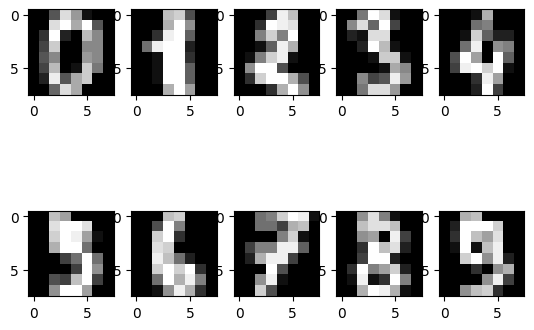

In [ ]:
#手書き画像の表示,X[0] の数値データの詳細です。数字が大きいセルほど白く、数字が小さいセルほど黒くなっています
import matplotlib.pyplot as plt
fig = plt.figure()

for i, x in enumerate(X[0:10], 0):
    sp = fig.add_subplot(2, 5, (i + 1))
    sp.imshow(x.reshape(8, 8), cmap = "gray") 

In [26]:
#データの前処理について,今回は不要
#データを訓練データとテストデータに分ける
#このテストデータは1800件弱ありますので、今回は1200件目までを訓練データ、1201件目以降をテストデータとします
X_train = X[:1200]
X_test  = X[1200:]
y_train = y[:1200]
y_test  = y[1200:]

In [27]:
#モデルを作成して訓練する,分類モデルを訓練したいので、今回も SVC の線形分類モデルを使います
from sklearn.svm import SVC
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [28]:
#期待する性能が出たかを評価,テストデータ X_test を分類器にかける
y_pred = classifier.predict(X_test)

In [31]:
y_pred

array([7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4,
       6, 6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8, 2, 0, 0, 1, 7, 6, 3, 2, 1, 7,
       4, 6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3, 8, 4, 0, 5, 3, 6, 9, 6, 6, 7,
       5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5, 4, 8, 8, 4, 9, 0, 8, 9, 8, 0,
       1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2,
       3, 4, 5, 6, 7, 8, 9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7,
       3, 5, 1, 0, 0, 2, 2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6,
       6, 4, 9, 1, 5, 0, 9, 6, 2, 8, 2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6,
       3, 1, 3, 9, 1, 7, 6, 8, 0, 3, 1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4,
       4, 7, 2, 8, 2, 2, 5, 7, 9, 5, 4, 8, 8, 4, 5, 0, 8, 0, 1, 2, 3, 4,
       5, 6, 7, 3, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6,
       7, 8, 9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0,
       0, 2, 2, 7, 8, 2, 0, 8, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 9,
       5, 0, 9, 5, 2, 3, 2, 0, 0, 9, 7, 6, 3, 2, 9,

In [32]:
y_test

array([7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4,
       6, 6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8, 2, 0, 0, 1, 7, 6, 3, 2, 1, 7,
       4, 6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3, 1, 4, 0, 5, 3, 6, 9, 6, 1, 7,
       5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5, 4, 8, 8, 4, 9, 0, 8, 9, 8, 0,
       1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2,
       3, 4, 5, 6, 7, 8, 9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7,
       3, 5, 1, 0, 0, 2, 2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6,
       6, 4, 9, 1, 5, 0, 9, 5, 2, 8, 2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6,
       3, 1, 3, 9, 1, 7, 6, 8, 4, 3, 1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4,
       4, 7, 2, 8, 2, 2, 5, 7, 9, 5, 4, 8, 8, 4, 9, 0, 8, 0, 1, 2, 3, 4,
       5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6,
       7, 8, 9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0,
       0, 2, 2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1,
       5, 0, 9, 5, 2, 8, 2, 0, 0, 1, 7, 6, 3, 2, 1,

In [29]:
#混同行列を見てみましょう
from sklearn import metrics
print(metrics.confusion_matrix(y_test, y_pred))

[[58  0  0  0  0  0  1  0  0  0]
 [ 0 53  0  0  0  0  1  0  2  5]
 [ 1  0 59  0  0  0  0  0  0  0]
 [ 0  0  0 52  0  1  0  2  7  0]
 [ 1  0  0  0 57  0  0  0  1  2]
 [ 0  0  0  0  0 58  1  0  0  0]
 [ 0  1  0  0  0  0 60  0  0  0]
 [ 0  0  0  0  0  0  0 61  0  0]
 [ 0  1  0  2  1  0  0  1 50  0]
 [ 0  0  0  1  0  2  0  1  1 53]]


In [30]:
#具体的な数値で結果をみていく
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97        59
           1       0.96      0.87      0.91        61
           2       1.00      0.98      0.99        60
           3       0.95      0.84      0.89        62
           4       0.98      0.93      0.96        61
           5       0.95      0.98      0.97        59
           6       0.95      0.98      0.97        61
           7       0.94      1.00      0.97        61
           8       0.82      0.91      0.86        55
           9       0.88      0.91      0.90        58

    accuracy                           0.94       597
   macro avg       0.94      0.94      0.94       597
weighted avg       0.94      0.94      0.94       597

